# Product Review Sentiment Analysis & Recommendation System

**Complete End-to-End Analysis in One Notebook**

This notebook performs comprehensive sentiment analysis and generates product recommendations from e-commerce review data.

## Table of Contents
1. [Setup & Data Loading](#setup)
2. [Phase 1: Data Exploration](#phase1)
3. [Phase 2: Brand & Category Extraction](#phase2)
4. [Phase 3: Sentiment Analysis](#phase3)
5. [Phase 4: Brand Affinity Analysis](#phase4)
6. [Phase 5: Recommendation System](#phase5)
7. [Phase 6: ML Model Training](#phase6)
8. [Summary & Insights](#summary)

## 1. Setup & Data Loading <a id='setup'></a>

Install required packages and import libraries.

In [52]:
# Install required packages (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn nltk textblob wordcloud openpyxl joblib -q

In [53]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud openpyxl joblib ipykernel


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [55]:
# Download NLTK data (run once)
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
print("✓ NLTK data downloaded")

✓ NLTK data downloaded


In [56]:
# Load the dataset
DATA_PATH = '../data/raw/GrammarandProductReviews.csv'

# Option 1: Load full dataset (71,045 reviews - may take time)
df = pd.read_csv(DATA_PATH)

# Option 2: Load sample for faster testing (uncomment to use)
# df = pd.read_csv(DATA_PATH, nrows=5000)  # Load first 5,000 rows
# df = pd.read_csv(DATA_PATH).sample(n=5000, random_state=42)  # Random 5,000 rows

print(f"✓ Loaded {len(df):,} reviews with {len(df.columns)} columns")
df.head()

✓ Loaded 71,044 reviews with 25 columns


,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.02537E+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,NaN,0.0,5,https://redsky.target.com/groot-domain-api/v1/...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,Joshua,6.02537E+11
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor. This review was collected as part...,Good,NaN,NaN,Dorothy W,73416000391
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor.,Good,NaN,NaN,Dorothy W,73416000391
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,113026909.0,NaN,1,https://www.walmart.com/reviews/product/43383370,I read through the reviews on here before look...,Disappointed,NaN,NaN,Rebecca,67981934427
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,171267657.0,NaN,1,https://www.walmart.com/reviews/product/43383370,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,Walker557,67981934427


## 2. Phase 1: Data Exploration <a id='phase1'></a>

Explore the dataset structure, statistics, and quality.

In [57]:
# Dataset info
print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\nData Types:")
print(df.dtypes)

DATASET INFORMATION

Shape: 71,044 rows × 25 columns

Column Names:
 1. id
 2. brand
 3. categories
 4. dateAdded
 5. dateUpdated
 6. ean
 7. keys
 8. manufacturer
 9. manufacturerNumber
10. name
11. reviews.date
12. reviews.dateAdded
13. reviews.dateSeen
14. reviews.didPurchase
15. reviews.doRecommend
16. reviews.id
17. reviews.numHelpful
18. reviews.rating
19. reviews.sourceURLs
20. reviews.text
21. reviews.title
22. reviews.userCity
23. reviews.userProvince
24. reviews.username
25. upc

Data Types:
id                       object
brand                    object
categories               object
dateAdded                object
dateUpdated              object
ean                      object
keys                     object
manufacturer             object
manufacturerNumber       object
name                     object
reviews.date             object
reviews.dateAdded        object
reviews.dateSeen         object
reviews.didPurchase      object
reviews.doRecommend      object
reviews.id   

In [58]:
# Missing values analysis
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("\nMISSING VALUES ANALYSIS")
print("="*80)
if len(missing_data) == 0:
    print("✓ No missing values found!")
else:
    print(missing_data.to_string(index=False))


MISSING VALUES ANALYSIS
              Column  Missing_Count  Missing_Percentage
reviews.userProvince          70595               99.37
    reviews.userCity          65634               92.39
 reviews.didPurchase          38886               54.74
          reviews.id          38886               54.74
  reviews.numHelpful          38536               54.24
                 ean          31979               45.01
 reviews.doRecommend          10615               14.94
       reviews.title            477                0.67
  manufacturerNumber            203                0.29
        manufacturer            141                0.20
    reviews.username            102                0.14
        reviews.date             67                0.09
        reviews.text             36                0.05
                 upc              2                0.00


In [59]:
# Basic statistics
print("\nRATING STATISTICS")
print("="*80)
print(df['reviews.rating'].describe())
print(f"\nRating Distribution:")
print(df['reviews.rating'].value_counts().sort_index())


RATING STATISTICS
count    71044.000000
mean         4.385747
std          1.067659
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reviews.rating, dtype: float64

Rating Distribution:
reviews.rating
1     3701
2     1833
3     4369
4    14598
5    46543
Name: count, dtype: int64


In [60]:
# Create review length features
df['review_length'] = df['reviews.text'].fillna('').astype(str).apply(len)
df['review_word_count'] = df['reviews.text'].fillna('').astype(str).apply(lambda x: len(str(x).split()))

print("\nREVIEW TEXT LENGTH STATISTICS")
print("="*80)
print("Character count:")
print(df['review_length'].describe())
print("\nWord count:")
print(df['review_word_count'].describe())


REVIEW TEXT LENGTH STATISTICS
Character count:
count    71044.000000
mean       208.886099
std        225.441355
min          0.000000
25%         78.000000
50%        136.000000
75%        254.000000
max       5865.000000
Name: review_length, dtype: float64

Word count:
count    71044.000000
mean        39.425891
std         42.188075
min          0.000000
25%         15.000000
50%         26.000000
75%         48.000000
max       1010.000000
Name: review_word_count, dtype: float64


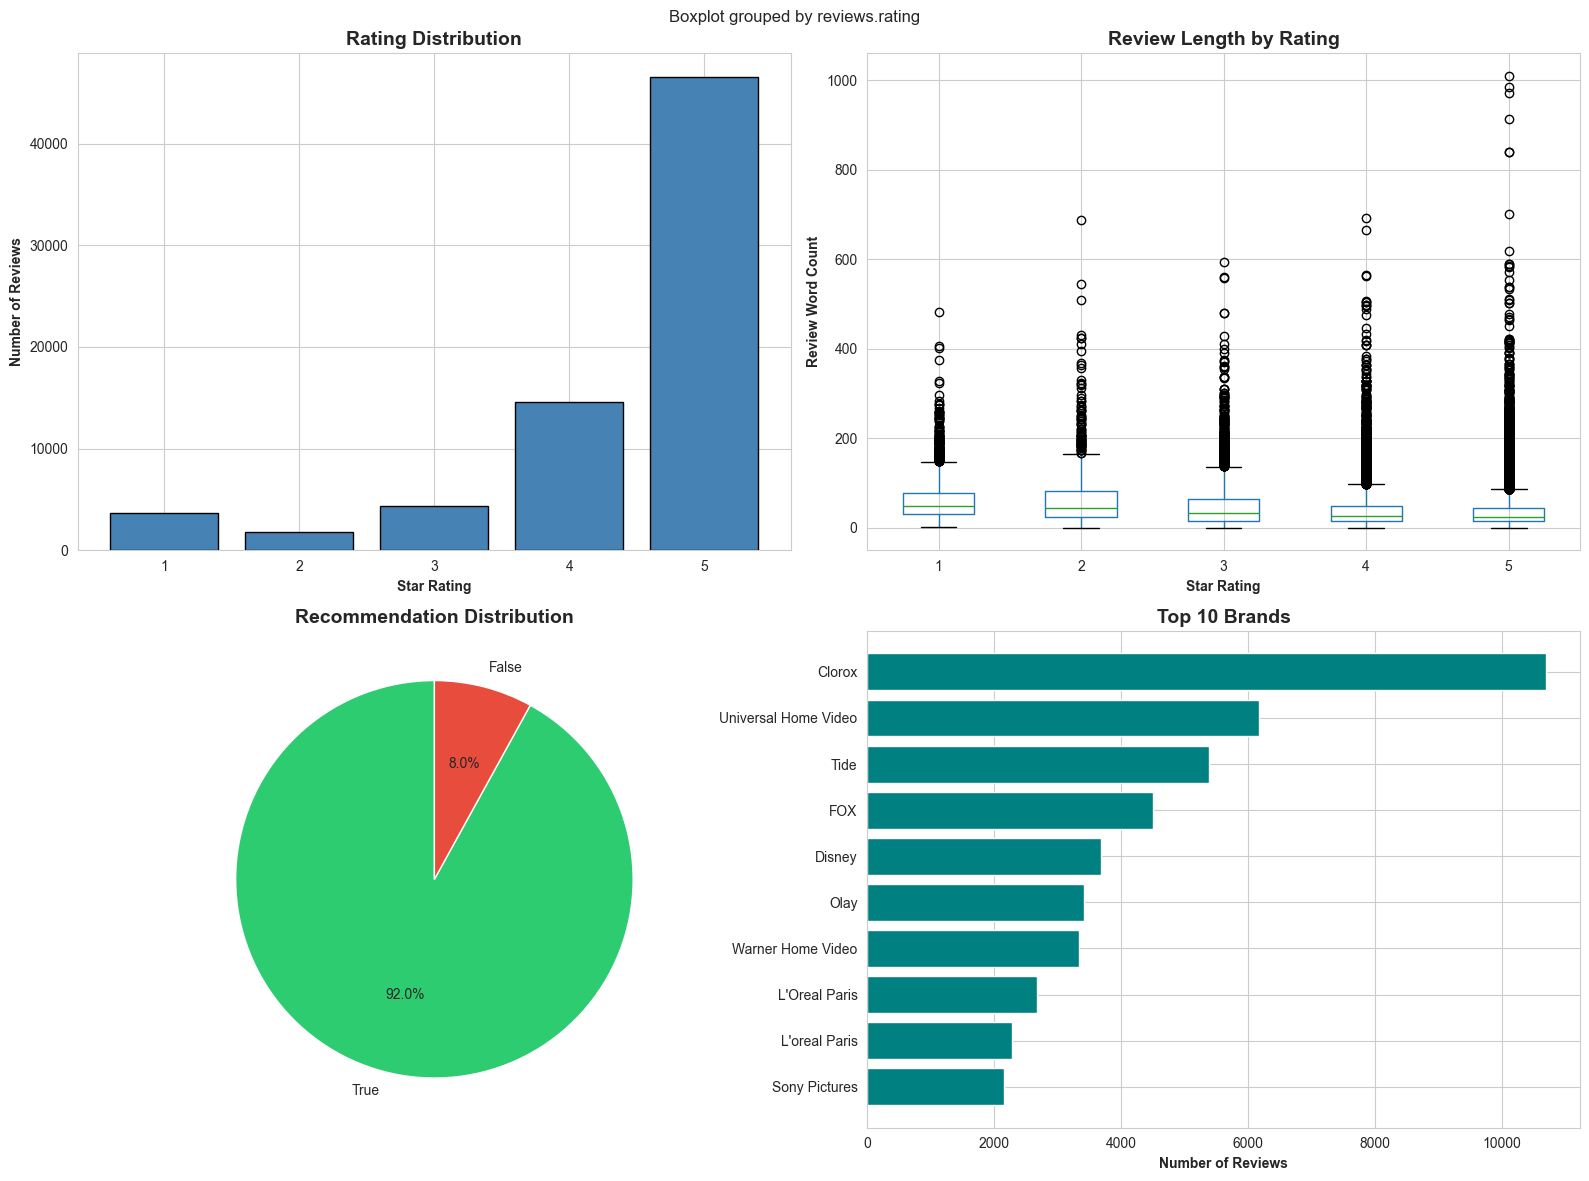

✓ Phase 1 Complete: Data Exploration


In [61]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating distribution
rating_counts = df['reviews.rating'].value_counts().sort_index()
axes[0, 0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Star Rating', fontweight='bold')
axes[0, 0].set_ylabel('Number of Reviews', fontweight='bold')
axes[0, 0].set_title('Rating Distribution', fontweight='bold', fontsize=14)
axes[0, 0].set_xticks(range(1, 6))

# 2. Review length by rating
df.boxplot(column='review_word_count', by='reviews.rating', ax=axes[0, 1])
axes[0, 1].set_xlabel('Star Rating', fontweight='bold')
axes[0, 1].set_ylabel('Review Word Count', fontweight='bold')
axes[0, 1].set_title('Review Length by Rating', fontweight='bold', fontsize=14)
plt.sca(axes[0, 1])
plt.xticks(range(1, 6))

# 3. Recommendation distribution
if 'reviews.doRecommend' in df.columns:
    rec_counts = df['reviews.doRecommend'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']
    axes[1, 0].pie(rec_counts.values, labels=rec_counts.index, autopct='%1.1f%%',
                   startangle=90, colors=colors[:len(rec_counts)])
    axes[1, 0].set_title('Recommendation Distribution', fontweight='bold', fontsize=14)

# 4. Top brands
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().head(10)
    axes[1, 1].barh(range(len(top_brands)), top_brands.values, color='teal')
    axes[1, 1].set_yticks(range(len(top_brands)))
    axes[1, 1].set_yticklabels(top_brands.index)
    axes[1, 1].set_xlabel('Number of Reviews', fontweight='bold')
    axes[1, 1].set_title('Top 10 Brands', fontweight='bold', fontsize=14)
    axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("✓ Phase 1 Complete: Data Exploration")

## 3. Phase 2: Brand & Category Extraction <a id='phase2'></a>

Extract and structure brand and category information.

In [62]:
# Clean brand names
df['brand_clean'] = df['brand'].fillna('Unknown').str.strip().str.title()

print("\nBRAND EXTRACTION")
print("="*80)
print(f"Unique brands: {df['brand_clean'].nunique()}")
print(f"\nTop 10 brands by review count:")
print(df['brand_clean'].value_counts().head(10))


BRAND EXTRACTION
Unique brands: 390

Top 10 brands by review count:
brand_clean
Clorox                  10700
Universal Home Video     6178
Tide                     5384
L'Oreal Paris            4971
Fox                      4498
Disney                   3692
Olay                     3420
Warner Home Video        3330
Sony Pictures            2161
Rubbermaid               1939
Name: count, dtype: int64


In [63]:
# Parse category hierarchy
df['category_list'] = df['categories'].fillna('').apply(
    lambda x: [cat.strip() for cat in str(x).split(',') if cat.strip()]
)

df['category_level_1'] = df['category_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
df['category_level_2'] = df['category_list'].apply(lambda x: x[1] if len(x) > 1 else '')
df['category_level_3'] = df['category_list'].apply(lambda x: x[2] if len(x) > 2 else '')

print("\nCATEGORY PARSING")
print("="*80)
print(f"\nLevel 1 Categories (Main):")
print(df['category_level_1'].value_counts().head(10))

all_categories = []
for cat_list in df['category_list']:
    all_categories.extend(cat_list)
print(f"\nTotal unique categories: {len(set(all_categories))}")


CATEGORY PARSING

Level 1 Categories (Main):
category_level_1
Movies                  17227
Household Essentials    16368
Personal Care           14141
Featured Brands          5623
Household Chemicals      4658
Beauty                   3479
Food                     2325
Movies & TV Shows        2160
Home                     1135
Kitchen & Dining          831
Name: count, dtype: int64

Total unique categories: 2123


In [64]:
# Brand-Category mapping
brand_category_map = df.groupby(['brand_clean', 'category_level_1']).size().reset_index(name='review_count')
brand_category_map = brand_category_map.sort_values('review_count', ascending=False)

print("\nBRAND-CATEGORY MAPPING (Top 20)")
print("="*80)
print(brand_category_map.head(20))

# Save mapping
brand_category_map.to_csv('../data/processed/brand_category_mapping.csv', index=False)
print("\n✓ Saved brand-category mapping")


BRAND-CATEGORY MAPPING (Top 20)
              brand_clean      category_level_1  review_count
83                 Clorox  Household Essentials          8606
382  Universal Home Video       Featured Brands          5510
119                   Fox                Movies          3741
102                Disney                Movies          3668
363                  Tide  Household Essentials          3498
253                  Olay         Personal Care          3420
397     Warner Home Video                Movies          3330
185         L'Oreal Paris         Personal Care          2683
184         L'Oreal Paris                Beauty          2288
332         Sony Pictures                Movies          2161
82                 Clorox   Household Chemicals          2094
296            Rubbermaid  Household Essentials          1939
396          Warner Bros.                Movies          1895
362                  Tide   Household Chemicals          1886
289      Quilted Northern  Household 

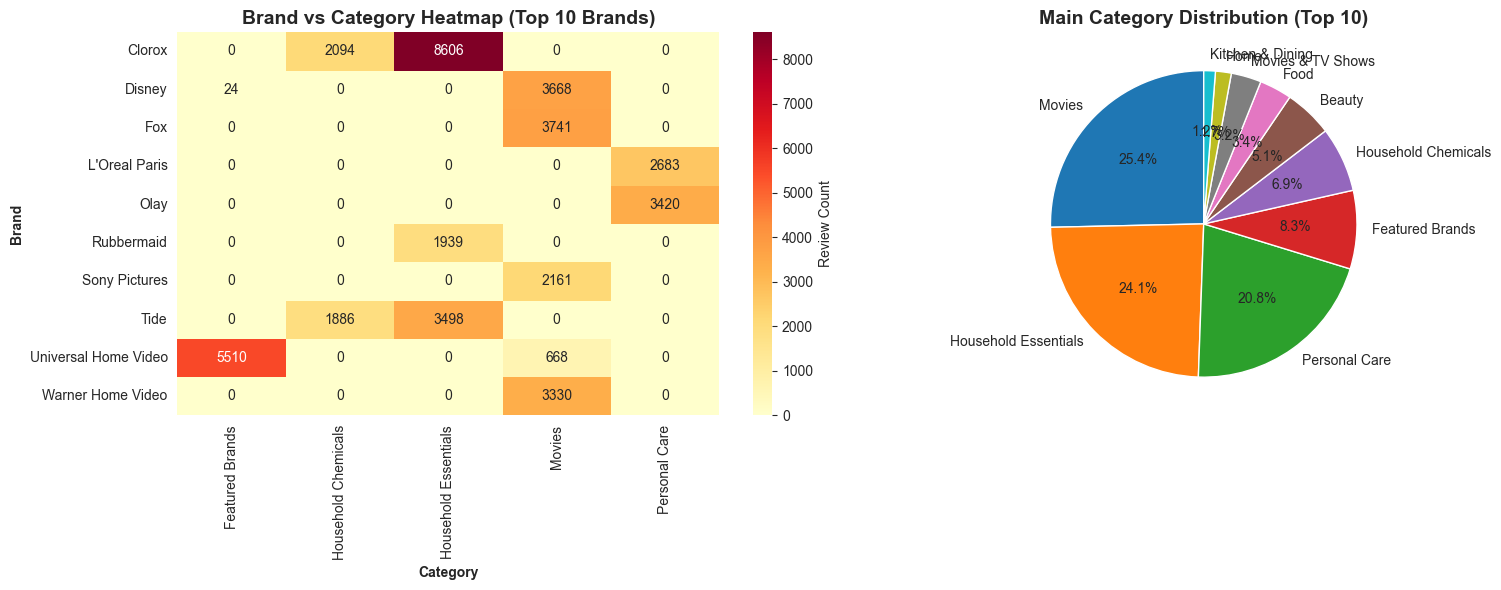

✓ Phase 2 Complete: Brand & Category Extraction


In [65]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Brand vs Category heatmap (top brands and categories)
top_brands_list = df['brand_clean'].value_counts().head(10).index
top_cats_list = df['category_level_1'].value_counts().head(5).index
df_subset = df[df['brand_clean'].isin(top_brands_list) & df['category_level_1'].isin(top_cats_list)]

pivot_table = pd.crosstab(df_subset['brand_clean'], df_subset['category_level_1'])
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Review Count'})
axes[0].set_xlabel('Category', fontweight='bold')
axes[0].set_ylabel('Brand', fontweight='bold')
axes[0].set_title('Brand vs Category Heatmap (Top 10 Brands)', fontweight='bold', fontsize=14)

# Category distribution
category_counts = df['category_level_1'].value_counts().head(10)
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Main Category Distribution (Top 10)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print("✓ Phase 2 Complete: Brand & Category Extraction")

## 4. Phase 3: Sentiment Analysis <a id='phase3'></a>

Perform multi-approach sentiment analysis.

In [66]:
# Rating-based sentiment
def label_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment_rating'] = df['reviews.rating'].apply(label_sentiment)

print("\nRATING-BASED SENTIMENT")
print("="*80)
print(df['sentiment_rating'].value_counts())
print(f"\nPercentages:")
print((df['sentiment_rating'].value_counts() / len(df) * 100).round(2))


RATING-BASED SENTIMENT
sentiment_rating
Positive    61141
Negative     5534
Neutral      4369
Name: count, dtype: int64

Percentages:
sentiment_rating
Positive    86.06
Negative     7.79
Neutral      6.15
Name: count, dtype: float64


In [67]:
# Text preprocessing
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isna(text) or text == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    try:
        tokens = word_tokenize(text)
    except:
        tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

print("\nTEXT PREPROCESSING")
print("="*80)
print("⏳ Preprocessing text... (this may take a few minutes)")
df['text_clean'] = df['reviews.text'].apply(preprocess_text)
print("✓ Text preprocessing complete")


TEXT PREPROCESSING
⏳ Preprocessing text... (this may take a few minutes)
✓ Text preprocessing complete


In [68]:
# VADER sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("\nVADER SENTIMENT ANALYSIS")
print("="*80)
print("⏳ Running VADER analysis... (this may take a few minutes)")

vader_scores = df['reviews.text'].fillna('').apply(lambda x: sia.polarity_scores(str(x)))
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])
df['vader_positive'] = vader_scores.apply(lambda x: x['pos'])
df['vader_negative'] = vader_scores.apply(lambda x: x['neg'])
df['vader_neutral'] = vader_scores.apply(lambda x: x['neu'])

def vader_category(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_vader'] = df['vader_compound'].apply(vader_category)

print("✓ VADER analysis complete")
print(f"\nVADER Compound Score Statistics:")
print(df['vader_compound'].describe())
print(f"\nVADER Sentiment Distribution:")
print(df['sentiment_vader'].value_counts())


VADER SENTIMENT ANALYSIS
⏳ Running VADER analysis... (this may take a few minutes)
✓ VADER analysis complete

VADER Compound Score Statistics:
count    71044.000000
mean         0.621446
std          0.402167
min         -0.985600
25%          0.510600
50%          0.777700
75%          0.891000
max          0.999400
Name: vader_compound, dtype: float64

VADER Sentiment Distribution:
sentiment_vader
Positive    62464
Negative     5445
Neutral      3135
Name: count, dtype: int64


In [69]:
# Combined sentiment score
df['rating_normalized'] = (df['reviews.rating'] - 1) / 4
df['vader_normalized'] = (df['vader_compound'] + 1) / 2
df['recommend_binary'] = df['reviews.doRecommend'].map({
    'TRUE': 1, 'True': 1, True: 1,
    'FALSE': 0, 'False': 0, False: 0
}).fillna(0.5)

df['combined_score'] = (
    df['rating_normalized'] * 0.4 +
    df['vader_normalized'] * 0.2 +
    df['recommend_binary'] * 0.4
)

def categorize_combined(score):
    if score > 0.7:
        return 'Highly Positive'
    elif score > 0.5:
        return 'Positive'
    elif score > 0.3:
        return 'Neutral'
    elif score > 0.15:
        return 'Negative'
    else:
        return 'Highly Negative'

df['sentiment_combined'] = df['combined_score'].apply(categorize_combined)

print("\nCOMBINED SENTIMENT SCORE")
print("="*80)
print(df['combined_score'].describe())
print(f"\nCombined Sentiment Distribution:")
print(df['sentiment_combined'].value_counts())


COMBINED SENTIMENT SCORE
count    71044.000000
mean         0.843574
std          0.221695
min          0.001440
25%          0.797100
50%          0.942010
75%          0.982680
max          0.999940
Name: combined_score, dtype: float64

Combined Sentiment Distribution:
sentiment_combined
Highly Positive    60294
Positive            3853
Neutral             2582
Negative            2453
Highly Negative     1862
Name: count, dtype: int64


In [70]:
# Sentiment validation
from sklearn.metrics import confusion_matrix, classification_report

agreement = (df['sentiment_rating'] == df['sentiment_vader']).sum()
agreement_pct = (agreement / len(df) * 100)

print("\nSENTIMENT VALIDATION")
print("="*80)
print(f"Rating vs VADER Agreement: {agreement:,}/{len(df):,} ({agreement_pct:.2f}%)")

cm = confusion_matrix(
    df['sentiment_rating'],
    df['sentiment_vader'],
    labels=['Negative', 'Neutral', 'Positive']
)
print(f"\nConfusion Matrix:")
print(cm)

print(f"\nClassification Report:")
print(classification_report(
    df['sentiment_rating'],
    df['sentiment_vader'],
    labels=['Negative', 'Neutral', 'Positive']
))


SENTIMENT VALIDATION
Rating vs VADER Agreement: 59,021/71,044 (83.08%)

Confusion Matrix:
[[ 2414   367  2753]
 [  697   284  3388]
 [ 2334  2484 56323]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.44      0.44      0.44      5534
     Neutral       0.09      0.07      0.08      4369
    Positive       0.90      0.92      0.91     61141

    accuracy                           0.83     71044
   macro avg       0.48      0.47      0.48     71044
weighted avg       0.82      0.83      0.82     71044



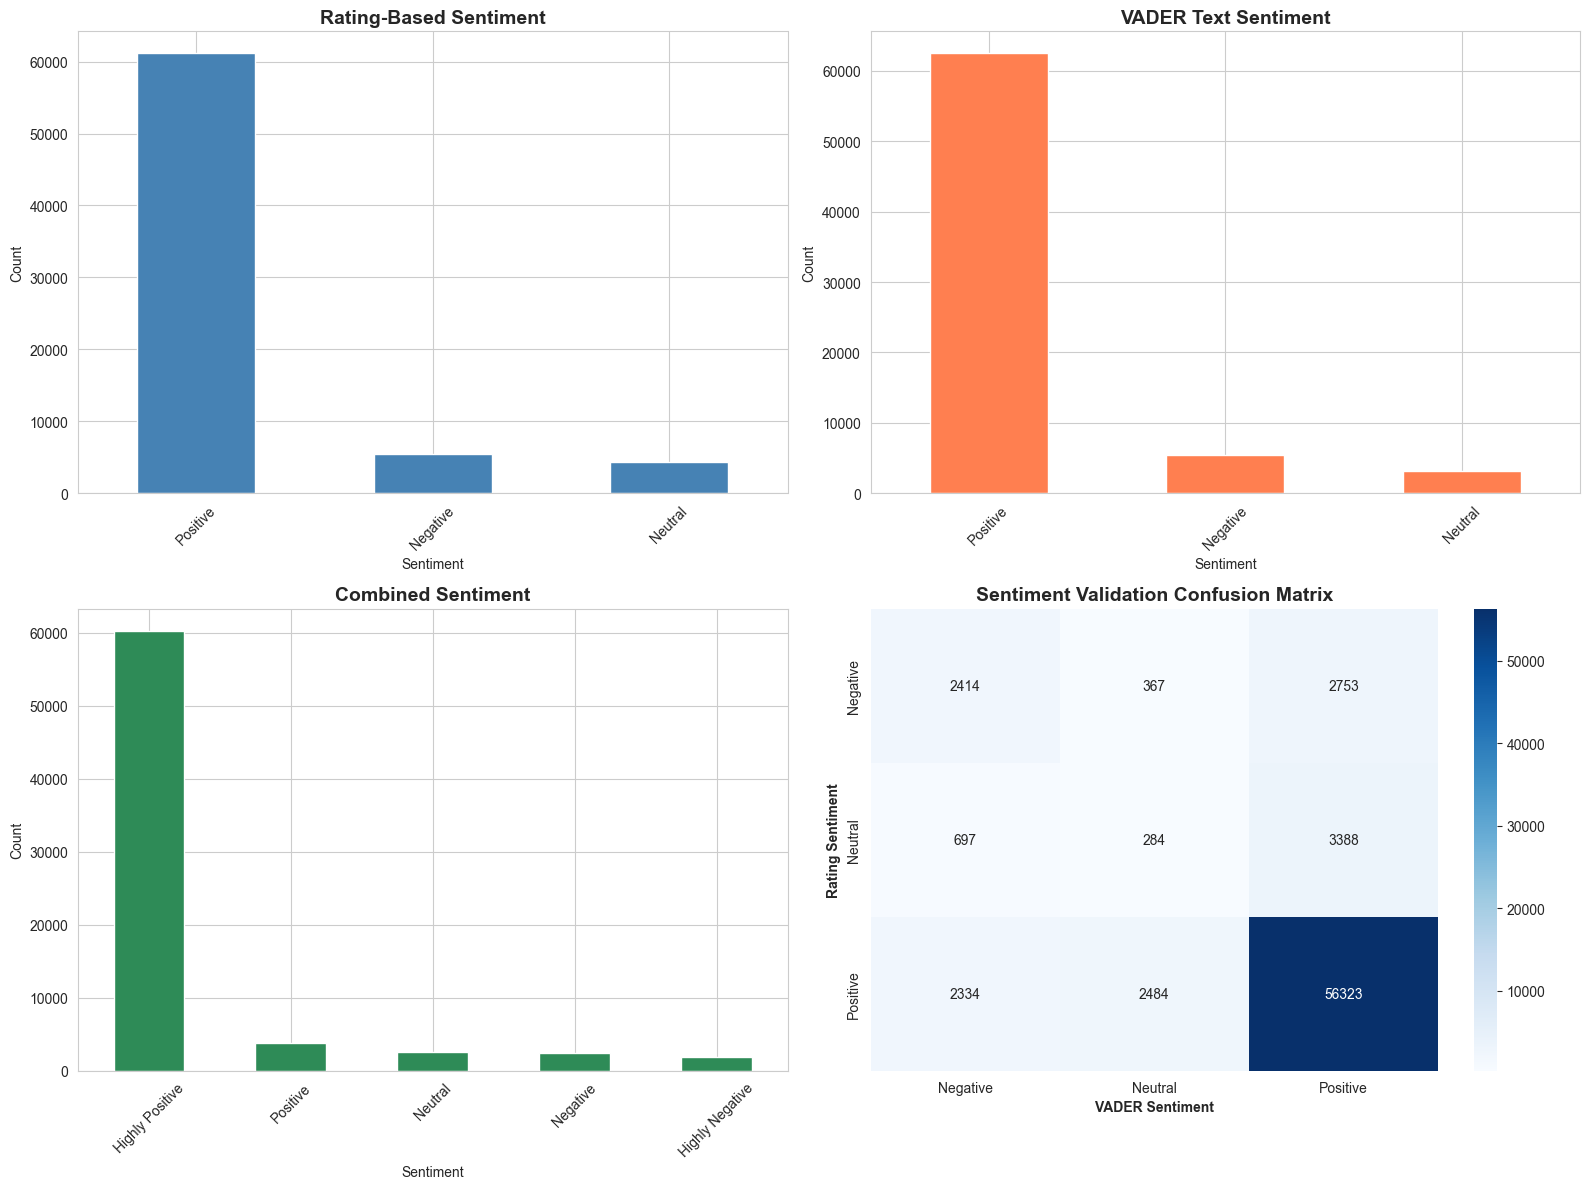

✓ Phase 3 Complete: Sentiment Analysis


In [71]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sentiment comparison
df['sentiment_rating'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Rating-Based Sentiment', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Sentiment')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

df['sentiment_vader'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('VADER Text Sentiment', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Sentiment')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

df['sentiment_combined'].value_counts().plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Combined Sentiment', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Sentiment')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
           xticklabels=['Negative', 'Neutral', 'Positive'],
           yticklabels=['Negative', 'Neutral', 'Positive'])
axes[1, 1].set_xlabel('VADER Sentiment', fontweight='bold')
axes[1, 1].set_ylabel('Rating Sentiment', fontweight='bold')
axes[1, 1].set_title('Sentiment Validation Confusion Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print("✓ Phase 3 Complete: Sentiment Analysis")

## 5. Phase 4: Brand Affinity Analysis <a id='phase4'></a>

Calculate brand performance metrics and extract insights.

In [72]:
# Brand affinity scoring
brand_agg = df.groupby('brand_clean').agg({
    'reviews.rating': 'mean',
    'combined_score': 'mean',
    'recommend_binary': lambda x: (x == 1).sum() / len(x) * 100,
    'id': 'count'
}).round(3)

brand_agg.columns = ['avg_rating', 'avg_sentiment', 'recommendation_rate', 'review_count']

# Positive sentiment percentage
positive_by_brand = df[df['sentiment_combined'].isin(['Positive', 'Highly Positive'])].groupby('brand_clean').size()
total_by_brand = df.groupby('brand_clean').size()
brand_agg['positive_sentiment_pct'] = (positive_by_brand / total_by_brand * 100).fillna(0).round(2)

# Brand Affinity Score
brand_agg['affinity_score'] = (
    (brand_agg['avg_rating'] / 5.0 * 0.3) +
    (brand_agg['avg_sentiment'] * 0.3) +
    (brand_agg['recommendation_rate'] / 100 * 0.4)
).round(3)

brand_agg = brand_agg.sort_values('affinity_score', ascending=False)

print("\nBRAND AFFINITY SCORES (Top 20)")
print("="*80)
print(brand_agg.head(20))

# Save results
brand_agg.to_csv('../data/processed/brand_affinity_scores.csv')
print("\n✓ Saved brand affinity scores")


BRAND AFFINITY SCORES (Top 20)
                            avg_rating  avg_sentiment  recommendation_rate  \
brand_clean                                                                  
Carson-Dellosa Publishing          5.0          0.998                100.0   
Healthy Skoop                      5.0          0.996                100.0   
Bebe Au Lait                       5.0          0.998                100.0   
Haagen-Dazs                        5.0          0.993                100.0   
Timekeeper                         5.0          0.993                100.0   
Black Radiance                     5.0          0.994                100.0   
Happy Family                       5.0          0.993                100.0   
Honey Bunches Of Oats              5.0          0.989                100.0   
Season Seafood                     5.0          0.990                100.0   
Inc International Concepts         5.0          0.991                100.0   
Hex Performance                 

In [73]:
# Consumer insights - word frequency
positive_reviews = df[df['sentiment_combined'].isin(['Positive', 'Highly Positive'])]
negative_reviews = df[df['sentiment_combined'].isin(['Negative', 'Highly Negative'])]

positive_text = ' '.join(positive_reviews['text_clean'].fillna('').astype(str))
negative_text = ' '.join(negative_reviews['text_clean'].fillna('').astype(str))

def get_top_words(text, n=20):
    words = text.split()
    word_counts = Counter(words)
    return word_counts.most_common(n)

print("\nCONSUMER INSIGHTS")
print("="*80)
print(f"\nTop 20 words in POSITIVE reviews:")
for word, count in get_top_words(positive_text):
    print(f"  {word}: {count:,}")

print(f"\nTop 20 words in NEGATIVE reviews:")
for word, count in get_top_words(negative_text):
    print(f"  {word}: {count:,}")


CONSUMER INSIGHTS

Top 20 words in POSITIVE reviews:
  product: 21,141
  movie: 20,886
  great: 20,009
  review: 18,399
  part: 18,110
  love: 17,446
  promotion: 17,042
  collected: 17,035
  use: 14,401
  good: 11,076
  skin: 9,790
  like: 9,705
  one: 8,998
  clean: 8,324
  really: 7,765
  hair: 7,514
  would: 6,910
  smell: 6,657
  using: 6,620
  wipe: 6,502

Top 20 words in NEGATIVE reviews:
  product: 2,188
  one: 1,208
  new: 1,135
  like: 1,062
  used: 1,007
  mop: 953
  use: 943
  would: 936
  formula: 915
  hair: 869
  time: 852
  pod: 837
  tide: 802
  back: 786
  year: 775
  old: 752
  using: 715
  bought: 702
  movie: 675
  get: 631


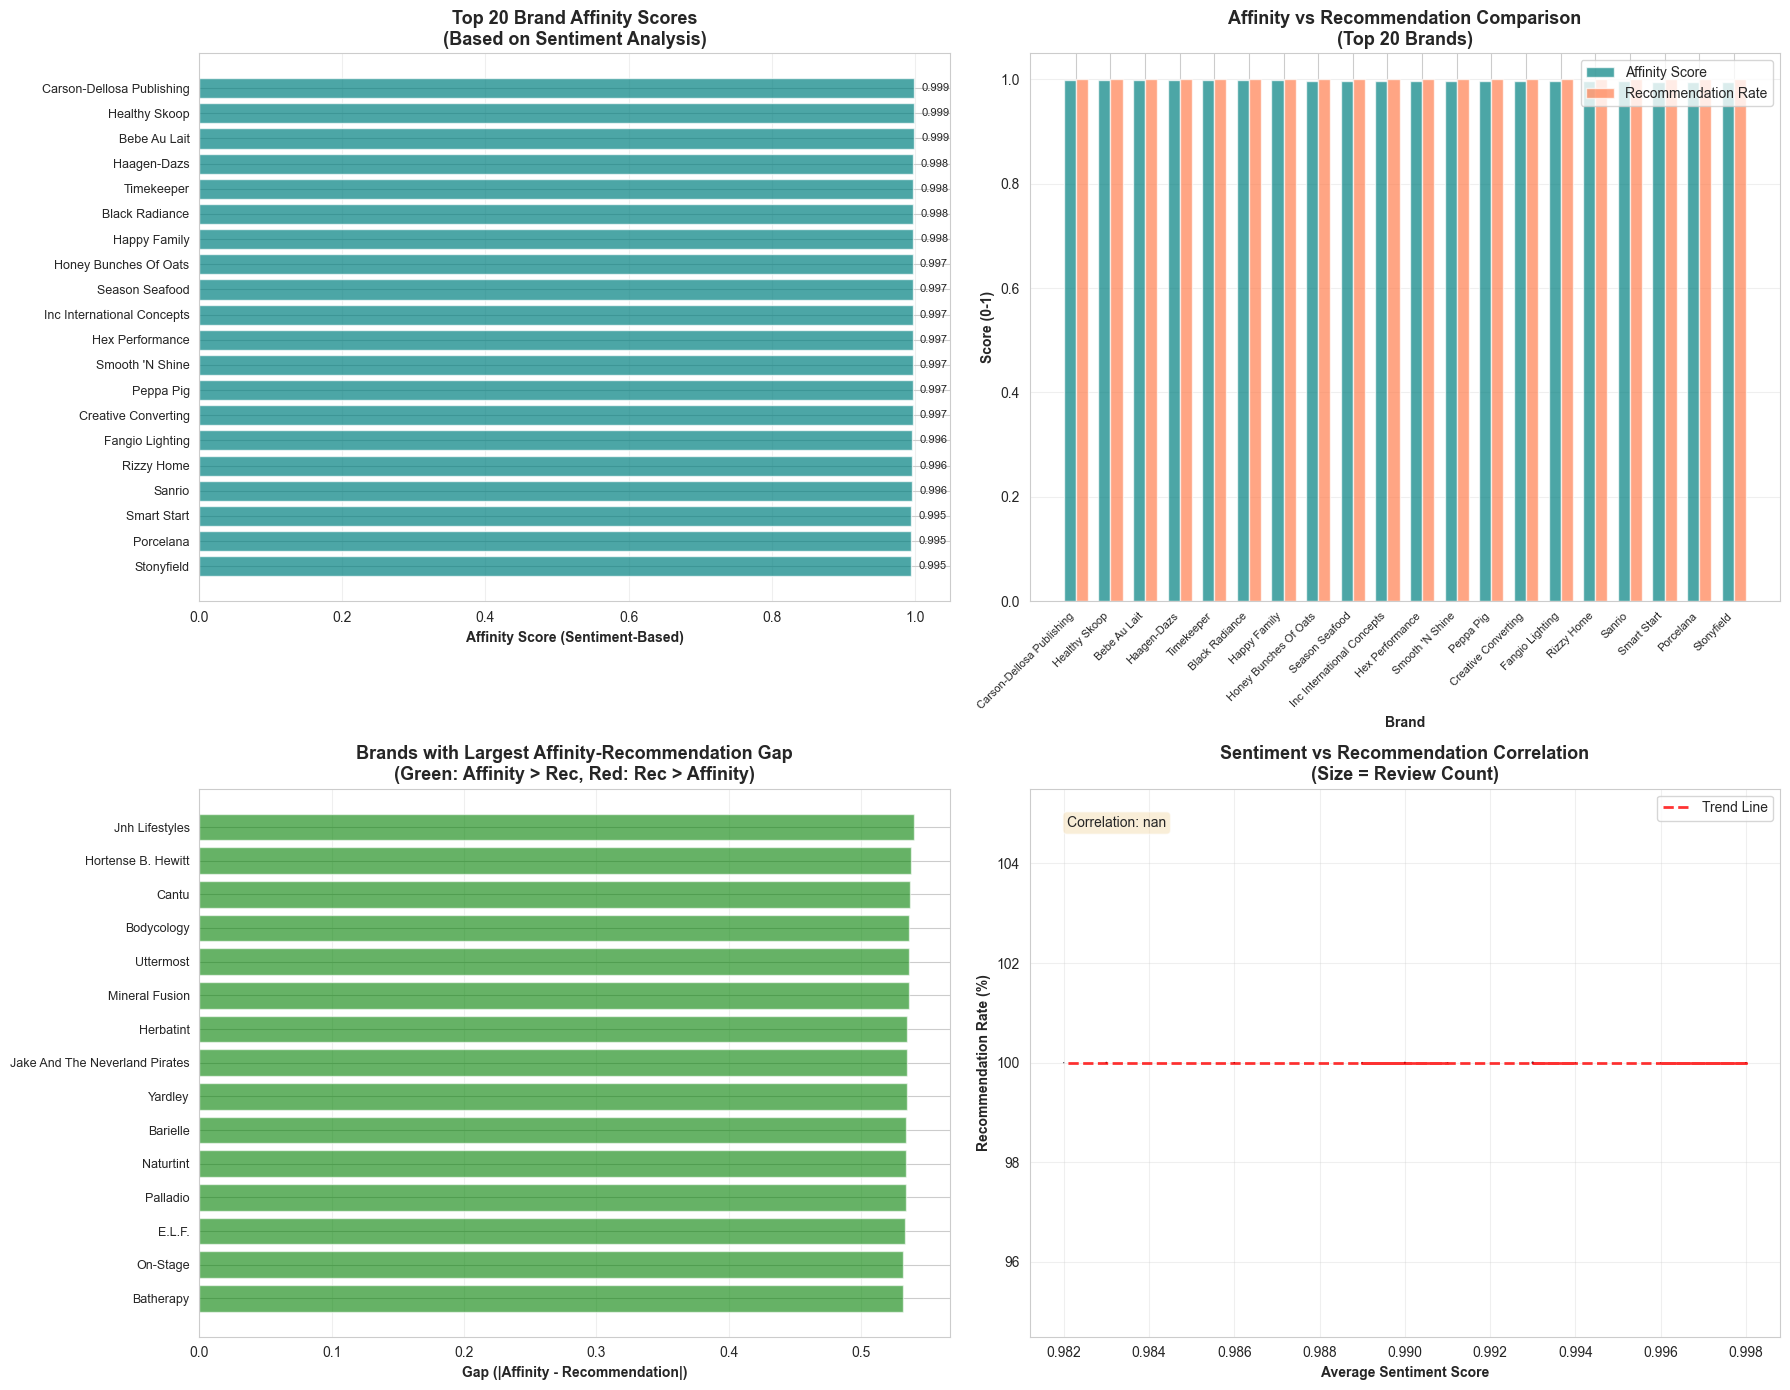

✓ Phase 4 Complete: Brand Affinity Analysis


In [74]:
# Improved Visualizations - More Distinct and Informative
top_20_brands = brand_agg.head(20)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Brand Affinity Scores (Horizontal Bar Chart)
axes[0, 0].barh(range(len(top_20_brands)), top_20_brands['affinity_score'], color='teal', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_20_brands)))
axes[0, 0].set_yticklabels(top_20_brands.index, fontsize=9)
axes[0, 0].set_xlabel('Affinity Score (Sentiment-Based)', fontweight='bold')
axes[0, 0].set_title('Top 20 Brand Affinity Scores\n(Based on Sentiment Analysis)', fontweight='bold', fontsize=13)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_20_brands['affinity_score']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

# 2. Affinity vs Recommendation Comparison (Grouped Bar Chart)
x = np.arange(len(top_20_brands))
width = 0.35
norm_rec_rate = top_20_brands['recommendation_rate'] / 100
axes[0, 1].bar(x - width/2, top_20_brands['affinity_score'], width, label='Affinity Score', color='teal', alpha=0.7)
axes[0, 1].bar(x + width/2, norm_rec_rate, width, label='Recommendation Rate', color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Brand', fontweight='bold')
axes[0, 1].set_ylabel('Score (0-1)', fontweight='bold')
axes[0, 1].set_title('Affinity vs Recommendation Comparison\n(Top 20 Brands)', fontweight='bold', fontsize=13)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(top_20_brands.index, rotation=45, ha='right', fontsize=8)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Brands with Largest Affinity-Recommendation Gap
brand_agg['gap'] = abs(brand_agg['affinity_score'] - brand_agg['recommendation_rate']/100)
top_gaps = brand_agg.nlargest(15, 'gap')
colors = ['green' if (row['affinity_score'] - row['recommendation_rate']/100) > 0 else 'red' for idx, row in top_gaps.iterrows()]
axes[1, 0].barh(range(len(top_gaps)), top_gaps['gap'], color=colors, alpha=0.6)
axes[1, 0].set_yticks(range(len(top_gaps)))
axes[1, 0].set_yticklabels(top_gaps.index, fontsize=9)
axes[1, 0].set_xlabel('Gap (|Affinity - Recommendation|)', fontweight='bold')
axes[1, 0].set_title('Brands with Largest Affinity-Recommendation Gap\n(Green: Affinity > Rec, Red: Rec > Affinity)', fontweight='bold', fontsize=13)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Sentiment vs Recommendation Scatter (with trend line)
# Use top 100 brands to show variation (top 20 all have 100% rec rate)
top_100_brands = brand_agg.head(100)
axes[1, 1].scatter(top_100_brands['affinity_score'], top_100_brands['recommendation_rate'],
                  s=top_20_brands['review_count']/5, alpha=0.6, color='purple', edgecolors='black', linewidth=0.5)
z = np.polyfit(top_20_brands['avg_sentiment'], top_20_brands['recommendation_rate'], 1)
p = np.poly1d(z)
axes[1, 1].plot(top_20_brands['avg_sentiment'], p(top_20_brands['avg_sentiment']), "r--", alpha=0.8, linewidth=2, label='Trend Line')
axes[1, 1].set_xlabel('Brand Affinity Score', fontweight='bold')
axes[1, 1].set_ylabel('Recommendation Rate (%)')
# Dynamic axis scaling
scores = top_100_brands['affinity_score']
rec_rates = top_100_brands['recommendation_rate']
min_score, max_score = scores.min(), scores.max()
min_rec, max_rec = rec_rates.min(), rec_rates.max()
score_range = max_score - min_score
rec_range = max_rec - min_rec
axes[1, 1].set_xlim(min_score - (score_range * 0.05 or 0.01), max_score + (score_range * 0.05 or 0.01))
axes[1, 1].set_ylim(max(0, min_rec - (rec_range * 0.1 or 2)), min(100, max_rec + (rec_range * 0.1 or 2)), fontweight='bold')
axes[1, 1].set_title('Sentiment vs Recommendation Correlation\n(Size = Review Count)', fontweight='bold', fontsize=13)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()
corr = np.corrcoef(top_20_brands['avg_sentiment'], top_20_brands['recommendation_rate'])[0,1]
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1, 1].transAxes, 
               fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Phase 4 Complete: Brand Affinity Analysis")

## 6. Phase 5: Recommendation System <a id='phase5'></a>

Build content-based recommendation engine.

In [75]:
# Create product profiles
product_profiles = df.groupby(['brand_clean', 'category_level_1']).agg({
    'reviews.rating': 'mean',
    'combined_score': 'mean',
    'recommend_binary': lambda x: (x == 1).sum() / len(x) * 100,
    'id': 'count',
    'sentiment_combined': lambda x: (x.isin(['Positive', 'Highly Positive'])).sum()
}).round(3)

product_profiles.columns = [
    'avg_rating', 'avg_sentiment', 'recommendation_rate',
    'review_count', 'positive_count'
]

negative_by_product = df[
    df['sentiment_combined'].isin(['Negative', 'Highly Negative'])
].groupby(['brand_clean', 'category_level_1']).size()

product_profiles['negative_count'] = negative_by_product
product_profiles['negative_count'] = product_profiles['negative_count'].fillna(0).astype(int)
product_profiles = product_profiles.reset_index()

print(f"\nCREATED {len(product_profiles):,} PRODUCT PROFILES")
print("="*80)
print(product_profiles.head(10))


CREATED 415 PRODUCT PROFILES
     brand_clean      category_level_1  avg_rating  avg_sentiment  \
0       4C Foods                  Food       5.000          0.964   
1         Adesso                  Home       5.000          0.857   
2      Advantage                  Home       4.000          0.691   
3  Africa'S Best         Personal Care       4.444          0.863   
4       Air Wick  Household Essentials       4.636          0.881   
5    Alberto Vo5         Personal Care       5.000          0.771   
6          Alera             Furniture       3.000          0.737   
7       All-Bran                  Food       4.909          0.926   
8          Almay         Personal Care       4.571          0.827   
9           Ambi         Personal Care       4.750          0.930   

   recommendation_rate  review_count  positive_count  negative_count  
0              100.000             6               6               0  
1               50.000             2               2               0

In [76]:
# Calculate recommendation scores
max_reviews = product_profiles['review_count'].max()

product_profiles['base_score'] = (
    (product_profiles['avg_rating'] / 5.0 * 0.25) +
    (product_profiles['avg_sentiment'] * 0.25) +
    (product_profiles['recommendation_rate'] / 100 * 0.30) +
    (np.log(product_profiles['review_count'] + 1) / np.log(max_reviews + 1) * 0.20)
)

product_profiles['recommendation_score'] = product_profiles['base_score']

# Apply boosts
product_profiles.loc[product_profiles['recommendation_rate'] == 100, 'recommendation_score'] += 0.1
product_profiles.loc[product_profiles['avg_rating'] >= 4.5, 'recommendation_score'] += 0.1
product_profiles.loc[product_profiles['avg_sentiment'] > 0.8, 'recommendation_score'] += 0.05

# Apply penalties
product_profiles.loc[product_profiles['recommendation_rate'] < 50, 'recommendation_score'] -= 0.2
product_profiles.loc[product_profiles['negative_count'] >= 3, 'recommendation_score'] -= 0.1

# Clip scores
product_profiles['recommendation_score'] = product_profiles['recommendation_score'].clip(0, 1)

print("\nRECOMMENDATION SCORE STATISTICS")
print("="*80)
print(product_profiles['recommendation_score'].describe())


RECOMMENDATION SCORE STATISTICS
count    415.000000
mean       0.654700
std        0.315032
min        0.000000
25%        0.367073
50%        0.732724
75%        0.959856
max        1.000000
Name: recommendation_score, dtype: float64


In [77]:
# Top-N recommendations
top_20 = product_profiles.sort_values('recommendation_score', ascending=False).head(20)

print("\nTOP 20 RECOMMENDED PRODUCTS")
print("="*80)
display_cols = ['brand_clean', 'category_level_1', 'avg_rating', 'avg_sentiment',
               'recommendation_rate', 'review_count', 'recommendation_score']
print(top_20[display_cols].to_string(index=False))

# Save recommendations
product_profiles.to_csv('../data/processed/top_recommendations.csv', index=False)
print("\n✓ Saved recommendations")

print("\n✓ Phase 5 Complete: Recommendation System")


TOP 20 RECOMMENDED PRODUCTS
              brand_clean         category_level_1  avg_rating  avg_sentiment  recommendation_rate  review_count  recommendation_score
                 4C Foods                     Food       5.000          0.964                100.0             6                   1.0
Carson-Dellosa Publishing School & Office Supplies       5.000          0.998                100.0             1                   1.0
              Hubba Bubba          Food & Beverage       5.000          0.964                100.0             1                   1.0
    Honey Bunches Of Oats                     Food       5.000          0.989                100.0             1                   1.0
            Hidden Valley          Food & Beverage       4.800          0.911                100.0             5                   1.0
          Hex Performance     Household Essentials       5.000          0.990                100.0             4                   1.0
                    Heinz 

## 7. Phase 6: ML Model Training <a id='phase6'></a>

Train and evaluate sentiment classification models.

In [78]:
# Prepare data for ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# Remove empty texts
df_clean = df[df['text_clean'].str.strip() != ''].copy()

X = df_clean['text_clean']
y = df_clean['sentiment_rating']

print("\nDATA PREPARATION FOR ML")
print("="*80)
print(f"Dataset size: {len(df_clean):,} reviews")
print(f"\nClass distribution:")
print(y.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Testing set: {len(X_test):,} samples")


DATA PREPARATION FOR ML
Dataset size: 70,998 reviews

Class distribution:
sentiment_rating
Positive    61102
Negative     5532
Neutral      4364
Name: count, dtype: int64

Training set: 56,798 samples
Testing set: 14,200 samples


In [79]:
# TF-IDF vectorization
print("\nCREATING TF-IDF FEATURES")
print("="*80)
print("⏳ Vectorizing text... (this may take a few minutes)")

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"✓ Feature matrix shape: {X_train_vec.shape}")


CREATING TF-IDF FEATURES
⏳ Vectorizing text... (this may take a few minutes)
✓ Feature matrix shape: (56798, 500)


In [80]:
# Train models
print("\nMODEL TRAINING")
print("="*80)

models = {}
results = {}

# Logistic Regression
print("\n⏳ Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)
models['Logistic Regression'] = lr_model
print("✓ Logistic Regression trained")

# Naive Bayes
print("\n⏳ Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
models['Naive Bayes'] = nb_model
print("✓ Naive Bayes trained")

# Random Forest
print("\n⏳ Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_vec, y_train)
models['Random Forest'] = rf_model
print("✓ Random Forest trained")

print(f"\n✓ Trained {len(models)} models")


MODEL TRAINING

⏳ Training Logistic Regression...
✓ Logistic Regression trained

⏳ Training Naive Bayes...
✓ Naive Bayes trained

⏳ Training Random Forest...
✓ Random Forest trained

✓ Trained 3 models


In [81]:
# Evaluate models
print("\nMODEL EVALUATION")
print("="*80)

for model_name, model in models.items():
    y_pred = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
    
    results[model_name] = {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm
    }

# Model comparison
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision (Positive)': [results[m]['report']['Positive']['precision'] for m in results.keys()],
    'Recall (Positive)': [results[m]['report']['Positive']['recall'] for m in results.keys()],
    'F1-Score (Positive)': [results[m]['report']['Positive']['f1-score'] for m in results.keys()]
})

comparison = comparison.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]['Model']
print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Accuracy: {comparison.iloc[0]['Accuracy']:.4f}")


MODEL EVALUATION

Logistic Regression:
  Accuracy: 0.8871

Naive Bayes:
  Accuracy: 0.8782

Random Forest:
  Accuracy: 0.8975

MODEL COMPARISON
              Model  Accuracy  Precision (Positive)  Recall (Positive)  F1-Score (Positive)
      Random Forest  0.897535              0.899556           0.993699             0.944287
Logistic Regression  0.887113              0.900749           0.984698             0.940855
        Naive Bayes  0.878239              0.886622           0.988626             0.934850

✓ Best Model: Random Forest
✓ Accuracy: 0.8975


In [82]:
# Save best model
import os
os.makedirs('../data/models', exist_ok=True)

joblib.dump(models[best_model_name], '../data/models/sentiment_classifier.pkl')
joblib.dump(vectorizer, '../data/models/tfidf_vectorizer.pkl')

print(f"\n✓ Saved {best_model_name} model")
print("✓ Saved TF-IDF vectorizer")
print("\n✓ Phase 6 Complete: ML Model Training")


✓ Saved Random Forest model
✓ Saved TF-IDF vectorizer

✓ Phase 6 Complete: ML Model Training


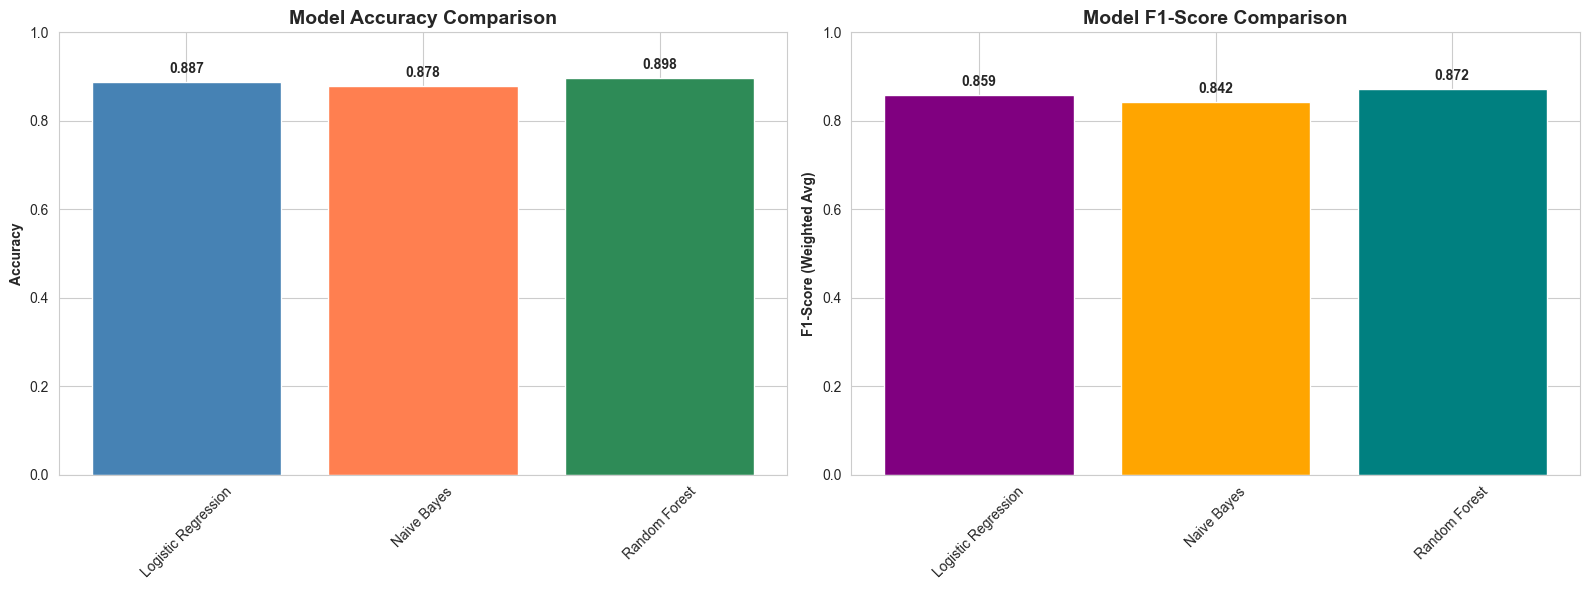

In [83]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model accuracy comparison
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

axes[0].bar(model_names, accuracies, color=['steelblue', 'coral', 'seagreen'])
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-scores comparison
f1_scores = [results[m]['report']['weighted avg']['f1-score'] for m in model_names]

axes[1].bar(model_names, f1_scores, color=['purple', 'orange', 'teal'])
axes[1].set_ylabel('F1-Score (Weighted Avg)', fontweight='bold')
axes[1].set_title('Model F1-Score Comparison', fontweight='bold', fontsize=14)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Summary & Insights <a id='summary'></a>

Key findings and business recommendations.

In [84]:
# Save processed dataset
df.to_csv('../data/processed/sentiment_labeled_data.csv', index=False)
print("✓ Saved complete processed dataset")

print("\n" + "="*80)
print("PROJECT SUMMARY")
print("="*80)

print(f"\n📊 Dataset Statistics:")
print(f"  • Total Reviews: {len(df):,}")
print(f"  • Unique Brands: {df['brand_clean'].nunique():,}")
print(f"  • Unique Categories: {len(set(all_categories)):,}")
print(f"  • Average Rating: {df['reviews.rating'].mean():.2f}/5.0")
print(f"  • Recommendation Rate: {(df['recommend_binary'] == 1).sum() / len(df) * 100:.1f}%")

print(f"\n🎯 Sentiment Analysis:")
print(f"  • Text-Rating Alignment: {agreement_pct:.1f}%")
print(f"  • Combined Score Mean: {df['combined_score'].mean():.2f}")
print(f"  • Highly Positive: {(df['sentiment_combined'] == 'Highly Positive').sum() / len(df) * 100:.1f}%")

print(f"\n🏆 Top 3 Brands (by Affinity):")
for i, (brand, row) in enumerate(brand_agg.head(3).iterrows(), 1):
    print(f"  {i}. {brand}: {row['affinity_score']:.3f} (Rating: {row['avg_rating']:.2f}, Rec: {row['recommendation_rate']:.1f}%)")

print(f"\n🤖 ML Model Performance:")
print(f"  • Best Model: {best_model_name}")
print(f"  • Accuracy: {comparison.iloc[0]['Accuracy']:.1%}")
print(f"  • F1-Score (Positive): {comparison.iloc[0]['F1-Score (Positive)']:.3f}")

print(f"\n📦 Generated Outputs:")
print(f"  • Processed Data: data/processed/sentiment_labeled_data.csv")
print(f"  • Brand Affinity: data/processed/brand_affinity_scores.csv")
print(f"  • Recommendations: data/processed/top_recommendations.csv")
print(f"  • ML Model: data/models/sentiment_classifier.pkl")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)

✓ Saved complete processed dataset

PROJECT SUMMARY

📊 Dataset Statistics:
  • Total Reviews: 71,044
  • Unique Brands: 390
  • Unique Categories: 2,123
  • Average Rating: 4.39/5.0
  • Recommendation Rate: 78.2%

🎯 Sentiment Analysis:
  • Text-Rating Alignment: 83.1%
  • Combined Score Mean: 0.84
  • Highly Positive: 84.9%

🏆 Top 3 Brands (by Affinity):
  1. Carson-Dellosa Publishing: 0.999 (Rating: 5.00, Rec: 100.0%)
  2. Healthy Skoop: 0.999 (Rating: 5.00, Rec: 100.0%)
  3. Bebe Au Lait: 0.999 (Rating: 5.00, Rec: 100.0%)

🤖 ML Model Performance:
  • Best Model: Random Forest
  • Accuracy: 89.8%
  • F1-Score (Positive): 0.944

📦 Generated Outputs:
  • Processed Data: data/processed/sentiment_labeled_data.csv
  • Brand Affinity: data/processed/brand_affinity_scores.csv
  • Recommendations: data/processed/top_recommendations.csv
  • ML Model: data/models/sentiment_classifier.pkl

✅ ANALYSIS COMPLETE!


## Next Steps

1. **API Deployment**: Use the saved models with the Flask API in `api/app.py`
2. **Further Analysis**: Explore temporal trends, user segmentation, aspect-based sentiment
3. **Model Improvement**: Try deep learning models (BERT), hyperparameter tuning
4. **Visualization**: Create interactive dashboards with Plotly or Streamlit

---

**Project Repository**: `/Users/manansharma/Desktop/Health/sentiment_recommendation_system/`